# 03 - RFM Analysis

# 03 - RFM Analysis

## Tujuan

Notebook ini digunakan untuk menganalisis perilaku customer
menggunakan metode RFM (Recency, Frequency, Monetary).

RFM terdiri dari:

- **Recency**: jumlah hari sejak transaksi terakhir customer.
- **Frequency**: jumlah transaksi unik yang dilakukan customer.
- **Monetary**: total nilai transaksi yang dihasilkan customer.

Tahapan analisis:

1. Load cleaned transaction data.
2. Menentukan analysis date.
3. Menghitung Recency.
4. Menghitung Frequency.
5. Menghitung Monetary.
6. Memvalidasi hasil RFM.
7. Membuat RFM Score.
8. Menganalisis distribusi RFM.
9. Mengekspor RFM dataset.

Hasil notebook ini akan digunakan pada tahap Customer Segmentation.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
transactions = pd.read_csv(
    "../data/processed/transactions_clean.csv",
    parse_dates=["transaction_date"]
)

In [5]:
transactions.head()

,transaction_id,customer_id,transaction_date,category,quantity,unit_price,discount_pct,revenue,payment_method
0,TRX0000001,CUST01170,2025-10-14,Beauty,1,241000,10,216900,E-Wallet
1,TRX0000002,CUST00686,2025-05-15,Beauty,1,37000,10,33300,COD
2,TRX0000003,CUST01245,2024-11-29,Fashion,2,74000,30,103600,Credit Card
3,TRX0000004,CUST00959,2024-11-09,Fashion,3,59000,30,123900,E-Wallet
4,TRX0000005,CUST00478,2025-06-19,Fashion,2,151000,10,271800,Credit Card


In [6]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    25000 non-null  object        
 1   customer_id       25000 non-null  object        
 2   transaction_date  25000 non-null  datetime64[ns]
 3   category          25000 non-null  object        
 4   quantity          25000 non-null  int64         
 5   unit_price        25000 non-null  int64         
 6   discount_pct      25000 non-null  int64         
 7   revenue           25000 non-null  int64         
 8   payment_method    25000 non-null  object        
dtypes: datetime64[ns](1), int64(4), object(4)
memory usage: 1.7+ MB


Periksa dataset sebelum RFM

In [7]:
print(
    f"Transactions : {len(transactions):,}"
)

print(
    f"Customers    : "
    f"{transactions['customer_id'].nunique():,}"
)

print(
    f"Date Range   : "
    f"{transactions['transaction_date'].min().date()}"
    f" - "
    f"{transactions['transaction_date'].max().date()}"
)

Transactions : 25,000
Customers    : 1,898
Date Range   : 2024-01-01 - 2025-12-31


In [8]:
analysis_date = (
    transactions["transaction_date"].max()
    + pd.Timedelta(days=1)
)

In [9]:
print(
    "Last transaction:",
    transactions["transaction_date"].max()
)

print(
    "Analysis date:",
    analysis_date
)

Last transaction: 2025-12-31 00:00:00
Analysis date: 2026-01-01 00:00:00


Customer Aggregation

In [10]:
last_purchase = (
    transactions
    .groupby("customer_id")[
        "transaction_date"
    ]
    .max()
)

In [11]:
last_purchase.head()

customer_id
CUST00001   2025-12-13
CUST00002   2025-12-13
CUST00004   2025-05-29
CUST00005   2025-11-10
CUST00006   2025-12-04
Name: transaction_date, dtype: datetime64[ns]

Hitung Recency secara manual

In [12]:
recency = (
    analysis_date
    - last_purchase
).dt.days

In [13]:
recency.head()

customer_id
CUST00001     19
CUST00002     19
CUST00004    217
CUST00005     52
CUST00006     28
Name: transaction_date, dtype: int64

Hitung Frequency

In [14]:
frequency = (
    transactions
    .groupby("customer_id")[
        "transaction_id"
    ]
    .nunique()
)

In [ ]:
Frequency vs Quantity

Hitung Monetary

In [15]:
monetary = (
    transactions
    .groupby("customer_id")[
        "revenue"
    ]
    .sum()
)

Gabungkan R, F, M

In [16]:
rfm = pd.DataFrame({
    "recency": recency,
    "frequency": frequency,
    "monetary": monetary
}).reset_index()

In [17]:
rfm.head()

,customer_id,recency,frequency,monetary
0,CUST00001,19,27,14614700
1,CUST00002,19,16,11428800
2,CUST00004,217,6,3279850
3,CUST00005,52,15,10582650
4,CUST00006,28,9,6056100


In [18]:
rfm = (
    transactions
    .groupby("customer_id")
    .agg(
        last_purchase=(
            "transaction_date",
            "max"
        ),

        frequency=(
            "transaction_id",
            "nunique"
        ),

        monetary=(
            "revenue",
            "sum"
        )
    )
    .reset_index()
)

In [19]:
rfm["recency"] = (
    analysis_date
    - rfm["last_purchase"]
).dt.days

In [20]:
rfm.head()

,customer_id,last_purchase,frequency,monetary,recency
0,CUST00001,2025-12-13,27,14614700,19
1,CUST00002,2025-12-13,16,11428800,19
2,CUST00004,2025-05-29,6,3279850,217
3,CUST00005,2025-11-10,15,10582650,52
4,CUST00006,2025-12-04,9,6056100,28


Susun kolom

In [21]:
rfm = rfm[
    [
        "customer_id",
        "last_purchase",
        "recency",
        "frequency",
        "monetary"
    ]
]

Validasi jumlah customer

In [22]:
transaction_customers = (
    transactions[
        "customer_id"
    ].nunique()
)

rfm_customers = len(rfm)

print(
    f"Transaction customers : "
    f"{transaction_customers:,}"
)

print(
    f"RFM customers         : "
    f"{rfm_customers:,}"
)

Transaction customers : 1,898
RFM customers         : 1,898


In [23]:
assert (
    transaction_customers
    == rfm_customers
)

Validasi customer_id

In [24]:
rfm[
    "customer_id"
].duplicated().sum()

np.int64(0)

In [25]:
assert (
    rfm["customer_id"]
    .duplicated()
    .sum()
    == 0
)

Validasi Recency

In [26]:
(rfm["recency"] < 0).sum()

np.int64(0)

In [27]:
assert (
    rfm["recency"] >= 0
).all()

Validasi Frequency

In [28]:
(rfm["frequency"] < 1).sum()

np.int64(0)

In [29]:
assert (
    rfm["frequency"] >= 1
).all()

Validasi Monetary

In [30]:
(rfm["monetary"] < 0).sum()

np.int64(0)

In [31]:
assert (
    rfm["monetary"] >= 0
).all()

Statistik RFM

In [32]:
rfm[
    [
        "recency",
        "frequency",
        "monetary"
    ]
].describe()

,recency,frequency,monetary
count,1898.000000,1898.000000,1.898000e+03
mean,101.113804,13.171760,6.297440e+06
std,131.963944,11.996222,6.466738e+06
min,1.000000,1.000000,1.680000e+04
25%,18.000000,5.000000,1.572312e+06
50%,48.000000,9.000000,4.302225e+06
75%,125.750000,19.000000,9.065875e+06
max,727.000000,108.000000,5.875395e+07


Median penting

In [33]:
rfm[
    [
        "recency",
        "frequency",
        "monetary"
    ]
].mean()

recency      1.011138e+02
frequency    1.317176e+01
monetary     6.297440e+06
dtype: float64

In [34]:
rfm[
    [
        "recency",
        "frequency",
        "monetary"
    ]
].median()

recency           48.0
frequency          9.0
monetary     4302225.0
dtype: float64

Visualisasi distribusi Recency

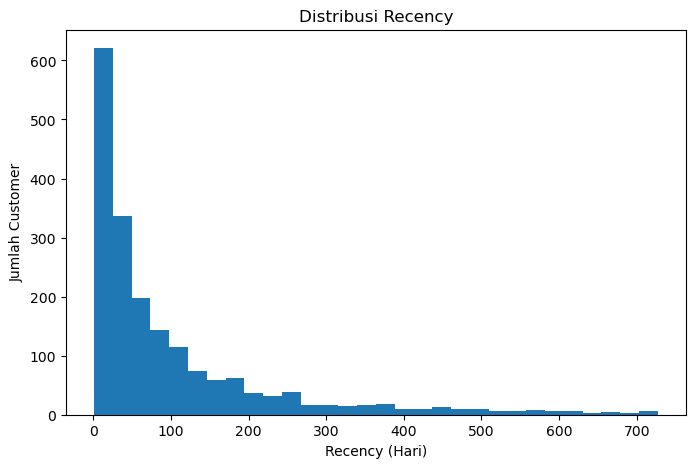

In [35]:
plt.figure(figsize=(8, 5))

plt.hist(
    rfm["recency"],
    bins=30
)

plt.title("Distribusi Recency")
plt.xlabel("Recency (Hari)")
plt.ylabel("Jumlah Customer")

plt.show()

Distribusi Frequency

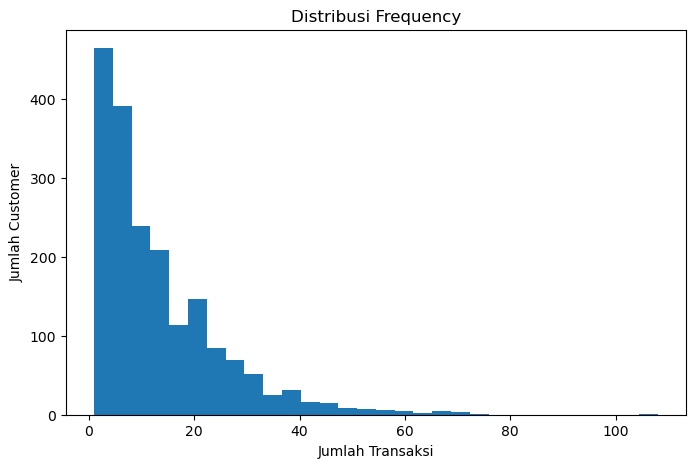

In [36]:
plt.figure(figsize=(8, 5))

plt.hist(
    rfm["frequency"],
    bins=30
)

plt.title("Distribusi Frequency")
plt.xlabel("Jumlah Transaksi")
plt.ylabel("Jumlah Customer")

plt.show()

Distribusi Monetary

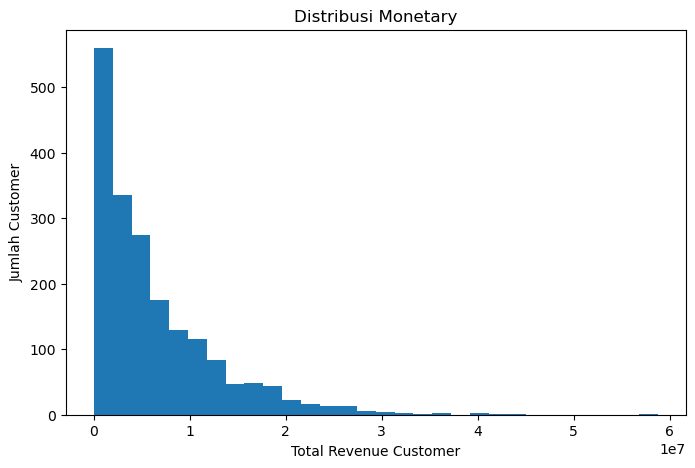

In [37]:
plt.figure(figsize=(8, 5))

plt.hist(
    rfm["monetary"],
    bins=30
)

plt.title("Distribusi Monetary")
plt.xlabel("Total Revenue Customer")
plt.ylabel("Jumlah Customer")

plt.show()

R Score

In [38]:
rfm["r_score"] = pd.qcut(
    rfm["recency"].rank(
        method="first"
    ),
    q=5,
    labels=[
        5,
        4,
        3,
        2,
        1
    ]
).astype(int)

Frequency Score

In [39]:
rfm["f_score"] = pd.qcut(
    rfm["frequency"].rank(
        method="first"
    ),
    q=5,
    labels=[
        1,
        2,
        3,
        4,
        5
    ]
).astype(int)

Monetary Score

In [40]:
rfm["m_score"] = pd.qcut(
    rfm["monetary"].rank(
        method="first"
    ),
    q=5,
    labels=[
        1,
        2,
        3,
        4,
        5
    ]
).astype(int)

Lihat hasil scoring

In [41]:
rfm[
    [
        "customer_id",
        "recency",
        "r_score",
        "frequency",
        "f_score",
        "monetary",
        "m_score"
    ]
].head(20)

,customer_id,recency,r_score,frequency,f_score,monetary,m_score
0,CUST00001,19,4,27,5,14614700,5
1,CUST00002,19,4,16,4,11428800,5
2,CUST00004,217,1,6,2,3279850,3
3,CUST00005,52,3,15,4,10582650,4
4,CUST00006,28,4,9,3,6056100,4
5,CUST00007,43,3,12,3,9159000,4
6,CUST00008,191,1,4,1,3418350,3
7,CUST00009,496,1,1,1,90750,1
8,CUST00010,652,1,1,1,235000,1
9,CUST00012,40,3,29,5,11246750,5


Validasi arah R Score

In [42]:
rfm[
    [
        "recency",
        "r_score"
    ]
].sort_values(
    "recency"
).head(20)

,recency,r_score
1539,1,5
861,1,5
621,1,5
77,1,5
1298,1,5
1296,1,5
71,1,5
340,1,5
558,1,5
22,1,5


In [43]:
rfm[
    [
        "recency",
        "r_score"
    ]
].sort_values(
    "recency",
    ascending=False
).head(20)

,recency,r_score
1574,727,1
1248,726,1
615,718,1
230,717,1
178,715,1
847,712,1
1592,697,1
916,696,1
575,687,1
569,677,1


Validasi Frequency Score

In [44]:
rfm[
    [
        "frequency",
        "f_score"
    ]
].sort_values(
    "frequency"
).head(20)

,frequency,f_score
1744,1,1
984,1,1
952,1,1
947,1,1
159,1,1
1651,1,1
919,1,1
916,1,1
901,1,1
899,1,1


In [45]:
rfm[
    [
        "frequency",
        "f_score"
    ]
].sort_values(
    "frequency",
    ascending=False
).head(20)

,frequency,f_score
981,108,5
658,74,5
437,72,5
368,71,5
776,69,5
1835,68,5
1847,68,5
712,67,5
1170,66,5
694,66,5


Validasi Monetary Score

In [46]:
rfm[
    [
        "monetary",
        "m_score"
    ]
].sort_values(
    "monetary"
).head(20)

,monetary,m_score
1268,16800,1
741,19550,1
1321,27200,1
615,27900,1
901,30800,1
651,31450,1
847,34000,1
1000,34200,1
899,36550,1
1560,36800,1


In [47]:
rfm[
    [
        "monetary",
        "m_score"
    ]
].sort_values(
    "monetary",
    ascending=False
).head(20)

,monetary,m_score
981,58753950,5
694,43092250,5
1554,41219900,5
154,40664250,5
1759,40596000,5
563,40272100,5
1847,35547800,5
1835,35537000,5
41,33553350,5
1170,31443650,5


Validasi range score

In [48]:
rfm[
    [
        "r_score",
        "f_score",
        "m_score"
    ]
].describe()

,r_score,f_score,m_score
count,1898.000000,1898.000000,1898.000000
mean,3.000000,3.000000,3.000000
std,1.414959,1.414959,1.414959
min,1.000000,1.000000,1.000000
25%,2.000000,2.000000,2.000000
50%,3.000000,3.000000,3.000000
75%,4.000000,4.000000,4.000000
max,5.000000,5.000000,5.000000


In [49]:
for column in [
    "r_score",
    "f_score",
    "m_score"
]:
    print(
        column,
        rfm[column].min(),
        rfm[column].max()
    )

r_score 1 5
f_score 1 5
m_score 1 5


In [50]:
assert rfm["r_score"].between(1, 5).all()
assert rfm["f_score"].between(1, 5).all()
assert rfm["m_score"].between(1, 5).all()

distribusi score

In [51]:
rfm["r_score"].value_counts().sort_index()

r_score
1    380
2    379
3    380
4    379
5    380
Name: count, dtype: int64

In [52]:
rfm["f_score"].value_counts().sort_index()

f_score
1    380
2    379
3    380
4    379
5    380
Name: count, dtype: int64

In [53]:
rfm["m_score"].value_counts().sort_index()

m_score
1    380
2    379
3    380
4    379
5    380
Name: count, dtype: int64

Buat tabel distribusi

In [54]:
score_distribution = pd.DataFrame({
    "R Score": (
        rfm["r_score"]
        .value_counts()
        .sort_index()
    ),

    "F Score": (
        rfm["f_score"]
        .value_counts()
        .sort_index()
    ),

    "M Score": (
        rfm["m_score"]
        .value_counts()
        .sort_index()
    )
})

score_distribution

,R Score,F Score,M Score
1,380,380,380
2,379,379,379
3,380,380,380
4,379,379,379
5,380,380,380


RFM Score

In [55]:
rfm["rfm_score"] = (
    rfm["r_score"].astype(str)
    + rfm["f_score"].astype(str)
    + rfm["m_score"].astype(str)
)

In [56]:
rfm[
    [
        "customer_id",
        "r_score",
        "f_score",
        "m_score",
        "rfm_score"
    ]
].head(20)

,customer_id,r_score,f_score,m_score,rfm_score
0,CUST00001,4,5,5,455
1,CUST00002,4,4,5,445
2,CUST00004,1,2,3,123
3,CUST00005,3,4,4,344
4,CUST00006,4,3,4,434
5,CUST00007,3,3,4,334
6,CUST00008,1,1,3,113
7,CUST00009,1,1,1,111
8,CUST00010,1,1,1,111
9,CUST00012,3,5,5,355


Total RFM Score

In [57]:
rfm["rfm_total_score"] = (
    rfm["r_score"]
    + rfm["f_score"]
    + rfm["m_score"]
)

In [58]:
rfm[
    "rfm_total_score"
].describe()

count    1898.000000
mean        9.000000
std         3.727966
min         3.000000
25%         6.000000
50%         9.000000
75%        12.000000
max        15.000000
Name: rfm_total_score, dtype: float64

Validasi Total Score

In [59]:
assert (
    rfm["rfm_total_score"]
    .between(3, 15)
    .all()
)

customer terbaik secara RFM

In [60]:
best_customers = rfm[
    rfm["rfm_score"] == "555"
].copy()

best_customers.head(20)

,customer_id,last_purchase,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,rfm_total_score
16,CUST00019,2025-12-22,10,62,26446300,5,5,5,555,15
26,CUST00029,2025-12-25,7,39,15718100,5,5,5,555,15
33,CUST00036,2025-12-29,3,52,17757350,5,5,5,555,15
58,CUST00061,2025-12-27,5,39,14030100,5,5,5,555,15
67,CUST00070,2025-12-27,5,49,21313950,5,5,5,555,15
70,CUST00074,2025-12-20,12,39,17008050,5,5,5,555,15
75,CUST00079,2025-12-22,10,24,10687850,5,5,5,555,15
83,CUST00087,2025-12-22,10,33,18738950,5,5,5,555,15
102,CUST00106,2025-12-29,3,54,30736250,5,5,5,555,15
136,CUST00143,2025-12-29,3,46,29215600,5,5,5,555,15


In [61]:
print(
    f"RFM 555 customers: "
    f"{len(best_customers):,}"
)

RFM 555 customers: 130


In [62]:
best_customers[
    [
        "recency",
        "frequency",
        "monetary"
    ]
].describe()

,recency,frequency,monetary
count,130.000000,130.000000,1.300000e+02
mean,6.738462,37.638462,1.914920e+07
std,3.467577,13.865357,7.400708e+06
min,1.000000,21.000000,1.062945e+07
25%,4.000000,27.000000,1.380239e+07
50%,7.000000,34.500000,1.754788e+07
75%,10.000000,44.000000,2.288040e+07
max,13.000000,108.000000,5.875395e+07


Top Customer berdasarkan Monetary

In [63]:
top_monetary = (
    rfm
    .sort_values(
        "monetary",
        ascending=False
    )
    .head(20)
)

top_monetary[
    [
        "customer_id",
        "recency",
        "frequency",
        "monetary",
        "rfm_score"
    ]
]

,customer_id,recency,frequency,monetary,rfm_score
981,CUST01047,1,108,58753950,555
694,CUST00739,4,66,43092250,555
1554,CUST01644,4,60,41219900,555
154,CUST00163,10,42,40664250,555
1759,CUST01856,25,56,40596000,455
563,CUST00599,31,61,40272100,455
1847,CUST01949,23,68,35547800,455
1835,CUST01937,14,68,35537000,455
41,CUST00044,60,48,33553350,355
1170,CUST01242,2,66,31443650,555


Top Frequency

In [64]:
top_frequency = (
    rfm
    .sort_values(
        "frequency",
        ascending=False
    )
    .head(20)
)

top_frequency[
    [
        "customer_id",
        "recency",
        "frequency",
        "monetary",
        "rfm_score"
    ]
]

,customer_id,recency,frequency,monetary,rfm_score
981,CUST01047,1,108,58753950,555
658,CUST00702,10,74,26156000,555
437,CUST00465,11,72,24144800,555
368,CUST00394,23,71,29701150,455
776,CUST00829,3,69,31163450,555
1835,CUST01937,14,68,35537000,455
1847,CUST01949,23,68,35547800,455
712,CUST00757,6,67,25041500,555
1170,CUST01242,2,66,31443650,555
694,CUST00739,4,66,43092250,555


Customer paling recent

In [65]:
most_recent = (
    rfm
    .sort_values(
        "recency"
    )
    .head(20)
)

most_recent[
    [
        "customer_id",
        "recency",
        "frequency",
        "monetary",
        "rfm_score"
    ]
]

,customer_id,recency,frequency,monetary,rfm_score
1539,CUST01629,1,20,9277250,544
861,CUST00916,1,7,931300,521
621,CUST00660,1,9,2994550,532
77,CUST00081,1,18,10632500,545
1298,CUST01378,1,23,9863950,554
1296,CUST01376,1,10,5806150,534
71,CUST00075,1,20,8685250,544
340,CUST00365,1,42,14140450,555
558,CUST00593,1,12,6753650,534
22,CUST00025,1,20,6276250,544


Customer lama tidak aktif

In [66]:
least_recent = (
    rfm
    .sort_values(
        "recency",
        ascending=False
    )
    .head(20)
)

least_recent[
    [
        "customer_id",
        "recency",
        "frequency",
        "monetary",
        "rfm_score"
    ]
]

,customer_id,recency,frequency,monetary,rfm_score
1574,CUST01664,727,1,168300,111
1248,CUST01323,726,1,234000,111
615,CUST00652,718,1,27900,111
230,CUST00248,717,1,168000,111
178,CUST00189,715,1,86400,111
847,CUST00902,712,1,34000,111
1592,CUST01683,697,1,774400,111
916,CUST00975,696,1,977000,111
575,CUST00611,687,1,38000,111
569,CUST00605,677,2,1339000,112


Hubungan Frequency dan Monetary

In [67]:
rfm[
    [
        "frequency",
        "monetary"
    ]
].corr()

,frequency,monetary
frequency,1.000000,0.874581
monetary,0.874581,1.000000


In [68]:
correlation = (
    rfm["frequency"]
    .corr(rfm["monetary"])
)

print(
    f"Correlation Frequency vs Monetary: "
    f"{correlation:.3f}"
)

Correlation Frequency vs Monetary: 0.875


Visualisasi Frequency vs Monetary

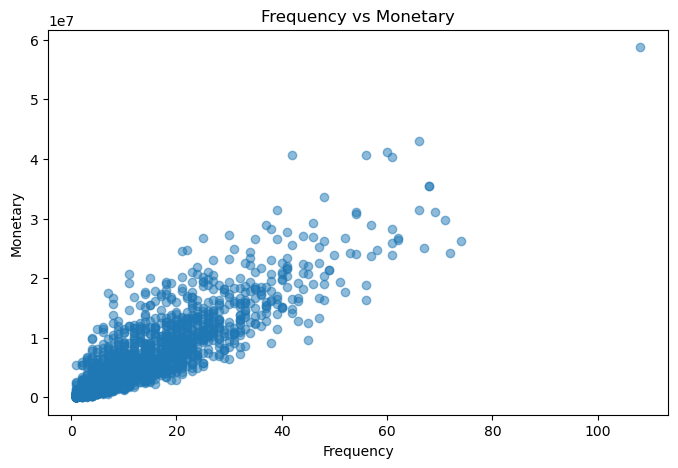

In [69]:
plt.figure(figsize=(8, 5))

plt.scatter(
    rfm["frequency"],
    rfm["monetary"],
    alpha=0.5
)

plt.title(
    "Frequency vs Monetary"
)

plt.xlabel(
    "Frequency"
)

plt.ylabel(
    "Monetary"
)

plt.show()

Recency vs Monetary

In [70]:
recency_monetary_corr = (
    rfm["recency"]
    .corr(rfm["monetary"])
)

print(
    f"Correlation Recency vs Monetary: "
    f"{recency_monetary_corr:.3f}"
)

Correlation Recency vs Monetary: -0.397


Visualisasi Recency vs Monetary

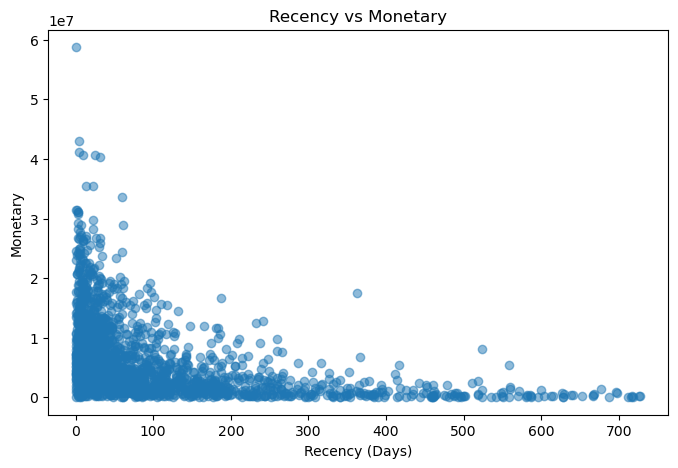

In [71]:
plt.figure(figsize=(8, 5))

plt.scatter(
    rfm["recency"],
    rfm["monetary"],
    alpha=0.5
)

plt.title(
    "Recency vs Monetary"
)

plt.xlabel(
    "Recency (Days)"
)

plt.ylabel(
    "Monetary"
)

plt.show()

RFM Correlation Matrix

In [72]:
rfm_correlation = rfm[
    [
        "recency",
        "frequency",
        "monetary"
    ]
].corr()

rfm_correlation

,recency,frequency,monetary
recency,1.000000,-0.446715,-0.396851
frequency,-0.446715,1.000000,0.874581
monetary,-0.396851,0.874581,1.000000


Analisis berdasarkan R Score

In [73]:
r_score_summary = (
    rfm
    .groupby("r_score")
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),
        avg_recency=(
            "recency",
            "mean"
        ),
        avg_frequency=(
            "frequency",
            "mean"
        ),
        avg_monetary=(
            "monetary",
            "mean"
        )
    )
    .reset_index()
)

r_score_summary

,r_score,customers,avg_recency,avg_frequency,avg_monetary
0,1,380,318.615789,3.960526,1.974185e+06
1,2,379,106.886544,8.548813,3.950880e+06
2,3,380,50.050000,13.042105,6.341252e+06
3,4,379,22.934037,18.348285,8.782878e+06
4,5,380,6.892105,21.960526,1.043837e+07


Analisis berdasarkan F Score

In [74]:
f_score_summary = (
    rfm
    .groupby("f_score")
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),
        avg_frequency=(
            "frequency",
            "mean"
        ),
        avg_monetary=(
            "monetary",
            "mean"
        )
    )
    .reset_index()
)

f_score_summary

,f_score,customers,avg_frequency,avg_monetary
0,1,380,2.147368,9.480182e+05
1,2,379,5.424802,2.667846e+06
2,3,380,9.565789,4.774653e+06
3,4,379,16.358839,7.811238e+06
4,5,380,32.350000,1.527988e+07


Analisis berdasarkan M Score

In [75]:
m_score_summary = (
    rfm
    .groupby("m_score")
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),
        avg_monetary=(
            "monetary",
            "mean"
        )
    )
    .reset_index()
)

m_score_summary

,m_score,customers,avg_monetary
0,1,380,5.332899e+05
1,2,379,2.062718e+06
2,3,380,4.304527e+06
3,4,379,7.803556e+06
4,5,380,1.677593e+07


Customer Value Contribution

In [76]:
total_monetary = (
    rfm["monetary"].sum()
)

In [77]:
m_score_contribution = (
    rfm
    .groupby("m_score")
    ["monetary"]
    .sum()
    .reset_index()
)

In [78]:
m_score_contribution[
    "revenue_percentage"
] = (
    m_score_contribution[
        "monetary"
    ]
    / total_monetary
    * 100
)

In [79]:
m_score_contribution

,m_score,monetary,revenue_percentage
0,1,202650150,1.695457
1,2,781770300,6.540620
2,3,1635720200,13.685125
3,4,2957547750,24.744092
4,5,6374852550,53.334706


### Monetary Score Analysis

Customer dengan M Score 5 merupakan kelompok dengan nilai
monetary tertinggi.

Berdasarkan hasil agregasi, kelompok tersebut menyumbang
sebesar **[HASIL]%** terhadap total monetary value.

Hal ini menunjukkan adanya konsentrasi nilai transaksi pada
customer bernilai tinggi.

Pareto Analysis Customer

In [81]:
pareto = (
    rfm
    .sort_values(
        "monetary",
        ascending=False
    )
    .copy()
)
pareto.head()

,customer_id,last_purchase,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,rfm_total_score
981,CUST01047,2025-12-31,1,108,58753950,5,5,5,555,15
694,CUST00739,2025-12-28,4,66,43092250,5,5,5,555,15
1554,CUST01644,2025-12-28,4,60,41219900,5,5,5,555,15
154,CUST00163,2025-12-22,10,42,40664250,5,5,5,555,15
1759,CUST01856,2025-12-07,25,56,40596000,4,5,5,455,14


Hitung cumulative monetary

In [82]:
pareto["cumulative_monetary"] = (
    pareto["monetary"]
    .cumsum()
)

Hitung cumulative revenue percentage

In [83]:
total_monetary = pareto["monetary"].sum()

In [84]:
pareto["cumulative_revenue_pct"] = (
    pareto["cumulative_monetary"]
    / total_monetary
    * 100
)

In [85]:
pareto[
    [
        "customer_id",
        "monetary",
        "cumulative_monetary",
        "cumulative_revenue_pct"
    ]
].head(20)

,customer_id,monetary,cumulative_monetary,cumulative_revenue_pct
981,CUST01047,58753950,58753950,0.491560
694,CUST00739,43092250,101846200,0.852088
1554,CUST01644,41219900,143066100,1.196951
154,CUST00163,40664250,183730350,1.537166
1759,CUST01856,40596000,224326350,1.876809
563,CUST00599,40272100,264598450,2.213742
1847,CUST01949,35547800,300146250,2.511150
1835,CUST01937,35537000,335683250,2.808468
41,CUST00044,33553350,369236600,3.089189
1170,CUST01242,31443650,400680250,3.352260


Hitung cumulative customer percentage

In [86]:
pareto["customer_rank"] = range(
    1,
    len(pareto) + 1
)

In [87]:
pareto["cumulative_customer_pct"] = (
    pareto["customer_rank"]
    / len(pareto)
    * 100
)

In [88]:
pareto[
    [
        "customer_id",
        "monetary",
        "cumulative_customer_pct",
        "cumulative_revenue_pct"
    ]
].head(20)

,customer_id,monetary,cumulative_customer_pct,cumulative_revenue_pct
981,CUST01047,58753950,0.052687,0.491560
694,CUST00739,43092250,0.105374,0.852088
1554,CUST01644,41219900,0.158061,1.196951
154,CUST00163,40664250,0.210748,1.537166
1759,CUST01856,40596000,0.263435,1.876809
563,CUST00599,40272100,0.316122,2.213742
1847,CUST01949,35547800,0.368809,2.511150
1835,CUST01937,35537000,0.421496,2.808468
41,CUST00044,33553350,0.474183,3.089189
1170,CUST01242,31443650,0.526870,3.352260


Berapa revenue dari Top 20% Customer?

In [89]:
top_20_customers = pareto[
    pareto["cumulative_customer_pct"] <= 20
]

In [90]:
top_20_revenue = (
    top_20_customers["monetary"].sum()
)

In [91]:
top_20_revenue_pct = (
    top_20_revenue
    / total_monetary
    * 100
)

In [92]:
print(
    f"Top 20% customers contribute "
    f"{top_20_revenue_pct:.2f}% "
    f"of total revenue."
)

Top 20% customers contribute 53.25% of total revenue.


Berapa customer yang menghasilkan 80% revenue?

In [93]:
customers_for_80 = pareto[
    pareto["cumulative_revenue_pct"] <= 80
]

In [94]:
customers_for_80 = pareto[
    pareto["cumulative_revenue_pct"] <= 80
]

In [95]:
customer_pct_for_80 = (
    len(customers_for_80)
    / len(pareto)
    * 100
)

In [96]:
print(
    f"Approximately "
    f"{customer_pct_for_80:.2f}% "
    f"of customers contribute "
    f"up to 80% of revenue."
)

Approximately 42.15% of customers contribute up to 80% of revenue.


In [97]:
threshold_80 = pareto[
    pareto["cumulative_revenue_pct"] >= 80
].iloc[0]

threshold_80[
    [
        "cumulative_customer_pct",
        "cumulative_revenue_pct"
    ]
]

cumulative_customer_pct    42.202318
cumulative_revenue_pct     80.010996
Name: 1393, dtype: object

Visualisasi Pareto

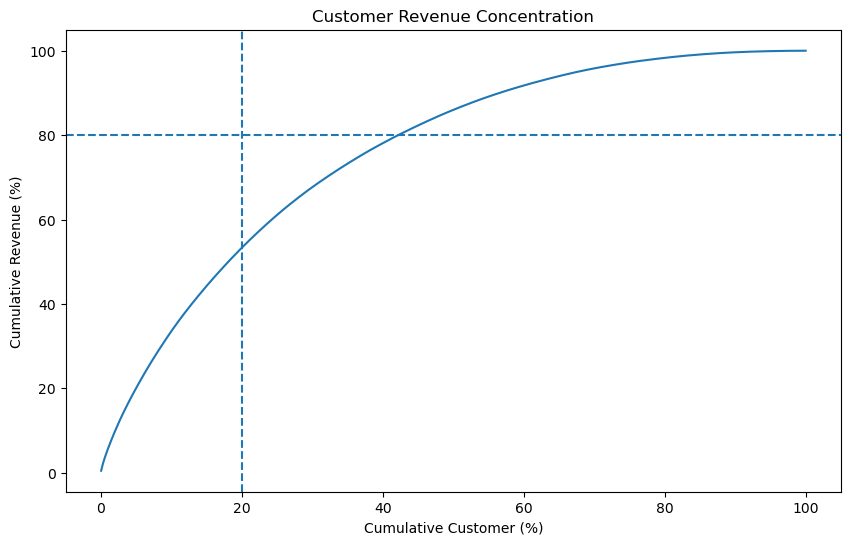

In [98]:
plt.figure(figsize=(10, 6))

plt.plot(
    pareto["cumulative_customer_pct"],
    pareto["cumulative_revenue_pct"]
)

plt.axhline(
    y=80,
    linestyle="--"
)

plt.axvline(
    x=20,
    linestyle="--"
)

plt.xlabel(
    "Cumulative Customer (%)"
)

plt.ylabel(
    "Cumulative Revenue (%)"
)

plt.title(
    "Customer Revenue Concentration"
)

plt.show()

Analisis Customer dengan RFM 555

In [99]:
rfm_555 = rfm[
    rfm["rfm_score"] == "555"
].copy()

In [100]:
print(
    f"RFM 555 customers : "
    f"{len(rfm_555):,}"
)

RFM 555 customers : 130


In [101]:
rfm_555_pct = (
    len(rfm_555)
    / len(rfm)
    * 100
)

print(
    f"Percentage        : "
    f"{rfm_555_pct:.2f}%"
)

Percentage        : 6.85%


In [102]:
potential_at_risk = rfm[
    (rfm["r_score"] <= 2)
    &
    (rfm["f_score"] >= 4)
    &
    (rfm["m_score"] >= 4)
].copy()

In [103]:
potential_at_risk[
    [
        "customer_id",
        "recency",
        "frequency",
        "monetary",
        "rfm_score"
    ]
].sort_values(
    "monetary",
    ascending=False
).head(20)

,customer_id,recency,frequency,monetary,rfm_score
554,CUST00589,92,21,18357650,245
1783,CUST01881,97,14,17640650,245
495,CUST00526,82,18,17411250,245
1866,CUST01969,74,43,16208100,255
157,CUST00166,92,33,15840400,255
37,CUST00040,88,15,15505900,245
1676,CUST01772,118,13,15433300,245
1149,CUST01221,91,40,15043950,255
1598,CUST01691,76,35,14956700,255
1045,CUST01113,103,33,14708650,255


Hitung jumlah Potential At Risk

In [105]:
print(
    "Potential At Risk:",
    len(potential_at_risk)
)

Potential At Risk: 55


In [106]:
potential_at_risk_value = (
    potential_at_risk[
        "monetary"
    ].sum()
)

print(
    f"Historical monetary value: "
    f"Rp{potential_at_risk_value:,.0f}"
)

Historical monetary value: Rp596,980,050


Customer Recent tetapi Frequency rendah

In [108]:
recent_low_frequency = rfm[
    (rfm["r_score"] >= 4)
    &
    (rfm["f_score"] <= 2)
].copy()

In [109]:
len(recent_low_frequency)

125

Analisis kombinasi RFM paling umum

In [110]:
rfm_score_distribution = (
    rfm["rfm_score"]
    .value_counts()
    .reset_index()
)

rfm_score_distribution.columns = [
    "rfm_score",
    "customer_count"
]

rfm_score_distribution.head(20)

,rfm_score,customer_count
0,111,175
1,555,130
2,455,95
3,211,59
4,344,55
5,222,54
6,444,53
7,122,47
8,233,44
9,544,42


persentase customer

In [111]:
rfm_score_distribution[
    "customer_percentage"
] = (
    rfm_score_distribution[
        "customer_count"
    ]
    / len(rfm)
    * 100
)

In [112]:
rfm_score_distribution.head(20)

,rfm_score,customer_count,customer_percentage
0,111,175,9.220232
1,555,130,6.849315
2,455,95,5.005269
3,211,59,3.108535
4,344,55,2.897787
5,222,54,2.845100
6,444,53,2.792413
7,122,47,2.476291
8,233,44,2.318230
9,544,42,2.212856


Validasi total Monetary terhadap Transaction Revenue

In [113]:
transaction_revenue = (
    transactions["revenue"].sum()
)

rfm_monetary = (
    rfm["monetary"].sum()
)

In [114]:
print(
    f"Transaction Revenue : "
    f"Rp{transaction_revenue:,.0f}"
)

print(
    f"RFM Monetary        : "
    f"Rp{rfm_monetary:,.0f}"
)

Transaction Revenue : Rp11,952,540,950
RFM Monetary        : Rp11,952,540,950


In [115]:
revenue_difference = (
    transaction_revenue
    - rfm_monetary
)

print(
    f"Difference          : "
    f"Rp{revenue_difference:,.0f}"
)

Difference          : Rp0


Assertion Monetary

In [116]:
assert (
    transaction_revenue
    == rfm_monetary
)

Validasi Frequency terhadap Total Transaction

In [117]:
transaction_count = (
    transactions[
        "transaction_id"
    ].nunique()
)

rfm_frequency = (
    rfm["frequency"].sum()
)

In [118]:
print(
    f"Unique Transactions : "
    f"{transaction_count:,}"
)

print(
    f"Total RFM Frequency : "
    f"{rfm_frequency:,}"
)

Unique Transactions : 25,000
Total RFM Frequency : 25,000


Validasi Last Purchase

In [119]:
sample_customer = (
    rfm.sample(
        1,
        random_state=42
    )
    ["customer_id"]
    .iloc[0]
)

sample_customer

'CUST00448'

In [120]:
transactions[
    transactions["customer_id"]
    == sample_customer
].sort_values(
    "transaction_date"
)

,transaction_id,customer_id,transaction_date,category,quantity,unit_price,discount_pct,revenue,payment_method
14165,TRX0014166,CUST00448,2024-02-13,Fashion,1,122000,15,103700,Bank Transfer
10531,TRX0010532,CUST00448,2024-02-14,Electronics,1,316000,40,189600,E-Wallet
4530,TRX0004531,CUST00448,2024-02-21,Home & Living,4,66000,15,224400,Bank Transfer
8467,TRX0008468,CUST00448,2024-03-12,Home & Living,1,84000,10,75600,Virtual Account
17663,TRX0017664,CUST00448,2024-06-17,Food & Beverage,1,133000,0,133000,Credit Card
8095,TRX0008096,CUST00448,2024-09-23,Home & Living,1,44000,10,39600,E-Wallet
4978,TRX0004979,CUST00448,2024-12-04,Electronics,1,128000,10,115200,Virtual Account
6283,TRX0006284,CUST00448,2025-03-24,Home & Living,2,75000,15,127500,E-Wallet
23587,TRX0023588,CUST00448,2025-07-01,Home & Living,1,487000,0,487000,Bank Transfer
10851,TRX0010852,CUST00448,2025-07-29,Fashion,3,109000,0,327000,COD


In [121]:
rfm[
    rfm["customer_id"]
    == sample_customer
]

,customer_id,last_purchase,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,rfm_total_score
420,CUST00448,2025-12-12,20,14,2357000,4,4,2,442,10


RFM Validation Report

In [122]:
rfm_validation = pd.DataFrame({
    "validation": [
        "Duplicate Customer ID",
        "Negative Recency",
        "Frequency < 1",
        "Negative Monetary",
        "Invalid R Score",
        "Invalid F Score",
        "Invalid M Score",
        "Revenue Difference",
        "Frequency Difference"
    ],

    "invalid_records": [
        rfm["customer_id"]
            .duplicated()
            .sum(),

        (rfm["recency"] < 0)
            .sum(),

        (rfm["frequency"] < 1)
            .sum(),

        (rfm["monetary"] < 0)
            .sum(),

        (~rfm["r_score"]
            .between(1, 5))
            .sum(),

        (~rfm["f_score"]
            .between(1, 5))
            .sum(),

        (~rfm["m_score"]
            .between(1, 5))
            .sum(),

        abs(
            transaction_revenue
            - rfm_monetary
        ),

        abs(
            transaction_count
            - rfm_frequency
        )
    ]
})

rfm_validation

,validation,invalid_records
0,Duplicate Customer ID,0
1,Negative Recency,0
2,Frequency < 1,0
3,Negative Monetary,0
4,Invalid R Score,0
5,Invalid F Score,0
6,Invalid M Score,0
7,Revenue Difference,0
8,Frequency Difference,0


Assertion final

In [123]:
assert (
    rfm_validation[
        "invalid_records"
    ] == 0
).all()

print(
    "✓ All RFM validation checks passed."
)

✓ All RFM validation checks passed.


Susun kolom final

In [124]:
rfm = rfm[
    [
        "customer_id",
        "last_purchase",
        "recency",
        "frequency",
        "monetary",
        "r_score",
        "f_score",
        "m_score",
        "rfm_score",
        "rfm_total_score"
    ]
]

In [125]:
rfm.head()

,customer_id,last_purchase,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,rfm_total_score
0,CUST00001,2025-12-13,19,27,14614700,4,5,5,455,14
1,CUST00002,2025-12-13,19,16,11428800,4,4,5,445,13
2,CUST00004,2025-05-29,217,6,3279850,1,2,3,123,6
3,CUST00005,2025-11-10,52,15,10582650,3,4,4,344,11
4,CUST00006,2025-12-04,28,9,6056100,4,3,4,434,11


Format Monetary hanya untuk display

In [126]:
rfm_display = rfm.copy()

rfm_display[
    "monetary_display"
] = (
    rfm_display["monetary"]
    .map(
        lambda x:
        f"Rp{x:,.0f}"
    )
)

In [127]:
rfm_display.head()

,customer_id,last_purchase,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,rfm_total_score,monetary_display
0,CUST00001,2025-12-13,19,27,14614700,4,5,5,455,14,"Rp14,614,700"
1,CUST00002,2025-12-13,19,16,11428800,4,4,5,445,13,"Rp11,428,800"
2,CUST00004,2025-05-29,217,6,3279850,1,2,3,123,6,"Rp3,279,850"
3,CUST00005,2025-11-10,52,15,10582650,3,4,4,344,11,"Rp10,582,650"
4,CUST00006,2025-12-04,28,9,6056100,4,3,4,434,11,"Rp6,056,100"


Export RFM Dataset

In [128]:
rfm.to_csv(
    "../data/processed/customer_rfm.csv",
    index=False
)

In [129]:
rfm_test = pd.read_csv(
    "../data/processed/customer_rfm.csv",
    parse_dates=["last_purchase"]
)

In [130]:
rfm_test.head()

,customer_id,last_purchase,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,rfm_total_score
0,CUST00001,2025-12-13,19,27,14614700,4,5,5,455,14
1,CUST00002,2025-12-13,19,16,11428800,4,4,5,445,13
2,CUST00004,2025-05-29,217,6,3279850,1,2,3,123,6
3,CUST00005,2025-11-10,52,15,10582650,3,4,4,344,11
4,CUST00006,2025-12-04,28,9,6056100,4,3,4,434,11


In [131]:
rfm_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   customer_id      1898 non-null   object        
 1   last_purchase    1898 non-null   datetime64[ns]
 2   recency          1898 non-null   int64         
 3   frequency        1898 non-null   int64         
 4   monetary         1898 non-null   int64         
 5   r_score          1898 non-null   int64         
 6   f_score          1898 non-null   int64         
 7   m_score          1898 non-null   int64         
 8   rfm_score        1898 non-null   int64         
 9   rfm_total_score  1898 non-null   int64         
dtypes: datetime64[ns](1), int64(8), object(1)
memory usage: 148.4+ KB


In [132]:
rfm_test.shape

(1898, 10)

RFM Analysis Summary

# RFM Analysis Summary

RFM Analysis dilakukan untuk mengukur nilai dan aktivitas
customer berdasarkan tiga dimensi:

## Recency

Mengukur jumlah hari sejak transaksi terakhir customer.

Semakin kecil nilai Recency, semakin baru customer melakukan
transaksi.

## Frequency

Mengukur jumlah transaksi unik yang dilakukan customer.

Semakin tinggi Frequency, semakin sering customer melakukan
pembelian.

## Monetary

Mengukur total nilai transaksi yang dihasilkan customer.

Semakin tinggi Monetary, semakin besar historical customer value.

## RFM Scoring

Masing-masing dimensi dibagi menjadi lima kelompok menggunakan
quintile scoring.

Score berada pada rentang:

1 = rendah

hingga

5 = tinggi / lebih baik.

Untuk Recency, arah scoring dibalik karena nilai Recency yang
lebih kecil menunjukkan aktivitas customer yang lebih baru.

## Validation

RFM dataset divalidasi untuk memastikan:

- satu row merepresentasikan satu customer;
- tidak terdapat Recency negatif;
- Frequency minimal satu transaksi;
- Monetary tidak negatif;
- score berada pada rentang 1–5;
- total Monetary sama dengan total transaction revenue;
- total Frequency sama dengan jumlah transaksi unik.

## Output

Dataset RFM disimpan pada:

`data/processed/customer_rfm.csv`

Dataset ini akan digunakan pada tahap berikutnya:

`04_customer_segmentation.ipynb`